# Red Siamesa para tenis (catalogo Innovasport)

Implementacion completa de los 5 pilares de una Red Siamesa, aplicada al catalogo de calzado deportivo:

1. **Datos** — tripletas `(Anchor, Positive, Negative)` mineadas con los atributos del JSON (`marca`, `modelo`, `descripcion`).
2. **Backbone** — DINOv2 ViT-B/14 **congelado** (mejor extractor que vimos en el notebook anterior).
3. **Cabeza siamesa** — MLP entrenable con pesos compartidos.
4. **Loss** — Triplet Loss con margen.
5. **Mining** — Hard Negative Mining sesgado por *marca + categoria* (productos similares).

**Datos disponibles en el JSON** (revisamos `notebooks/data/innovasport_productos.json`):

- `marca` -> 8 marcas (NIKE 75, ADIDAS 61, UNDER ARMOUR 22, PUMA 21, ...). Util como etiqueta para hard mining.
- `modelo` / `sku` -> 213 unicos. Como solo hay 1 imagen por modelo, el `Positive` se construye con **data augmentation** del propio Anchor.
- `descripcion` -> texto libre del que extraemos una **categoria deportiva** por keywords (running, futbol, basquetbol, casual, ...). Permite refinar el mining.
- `genero` -> casi todo 'hombres', poco discriminante.

**Idea del mining**: para cada Anchor de marca *NIKE*+*running*, el Negative mas duro es **otro NIKE running** (no un tenis de futbol de otra marca, eso seria un negativo facil). Asi la red aprende detalles finos.

## 0) Imports + setup

In [1]:
from pathlib import Path
from collections import Counter
import json
import hashlib
import re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cuda


## 1) Cargar JSON + indexar imagenes locales

Reutilizamos la carpeta `notebooks/data/productos/` ya creada por el notebook anterior. Cada imagen local se identifica por `md5(url)` + extension, asi podemos asociarla con su registro JSON.

In [2]:
json_candidates = [
    Path('notebooks/data/innovasport_productos.json'),
    Path('data/innovasport_productos.json'),
]
json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('No se encontro innovasport_productos.json')

with json_path.open('r', encoding='utf-8') as f:
    productos = json.load(f)

download_dir = json_path.parent / 'productos'
download_dir.mkdir(parents=True, exist_ok=True)


def url_to_filename(url):
    ext = '.jpg'
    low = url.lower()
    if '.png' in low:   ext = '.png'
    elif '.webp' in low: ext = '.webp'
    elif '.jpeg' in low: ext = '.jpeg'
    return hashlib.md5(url.encode('utf-8')).hexdigest() + ext


# Construye items con todos los atributos relevantes para mining
items = []
for p in productos:
    url = p.get('imagen_principal')
    if not isinstance(url, str) or not url.strip():
        continue
    fname = url_to_filename(url.strip())
    fpath = download_dir / fname
    if not fpath.exists():
        continue  # solo trabajamos con imagenes ya descargadas
    items.append({
        'path': fpath,
        'titulo': str(p.get('titulo', '')).strip(),
        'marca': str(p.get('marca', 'N/A')).strip().upper(),
        'modelo': str(p.get('modelo', '')).strip(),
        'sku': str(p.get('sku', '')).strip(),
        'descripcion': str(p.get('descripcion', '')).strip(),
    })

print(f'JSON: {json_path}')
print(f'Carpeta de imagenes: {download_dir}')
print(f'Productos con imagen local: {len(items)}')
print(f'Marcas: {Counter(x["marca"] for x in items).most_common()}')

JSON: data\innovasport_productos.json
Carpeta de imagenes: data\productos
Productos con imagen local: 213
Marcas: [('NIKE', 75), ('ADIDAS', 61), ('UNDER ARMOUR', 22), ('PUMA', 21), ('ASICS', 12), ('NEW BALANCE', 11), ('ON', 8), ('N/A', 2), ('REEBOK', 1)]


## 2) Categoria deportiva desde la descripcion (keywords)

El JSON no trae categoria explicita, pero la `descripcion` casi siempre contiene la disciplina. Mapeamos por keywords a una etiqueta corta. Si no detectamos nada -> `general`.

In [3]:
CAT_KEYWORDS = {
    'running':    ['correr', 'running', 'runner', 'maraton'],
    'futbol':     ['futbol', 'futbolista', 'soccer', 'cancha'],
    'basquetbol': ['basquetbol', 'basketball', 'basquet', 'baloncesto'],
    'training':   ['entrenamiento', 'crossfit', 'gym', 'gimnasio', 'training'],
    'casual':     ['casual', 'lifestyle', 'urbano', 'sportswear', 'estilo de vida'],
    'tenis_d':    ['tenista', 'tenis de cancha', 'padel'],
    'senderismo': ['senderismo', 'trail', 'montana', 'outdoor'],
}

_re_word = re.compile(r'[a-zA-ZáéíóúñÁÉÍÓÚÑ]+')

def categoria_desde_desc(desc):
    txt = ' '.join(_re_word.findall(desc.lower()))
    for cat, kws in CAT_KEYWORDS.items():
        if any(kw in txt for kw in kws):
            return cat
    return 'general'

for it in items:
    it['categoria'] = categoria_desde_desc(it['descripcion'])

print('Distribucion de categorias detectadas:')
for c, n in Counter(x['categoria'] for x in items).most_common():
    print(f'  {c:12s}  {n:4d}')

# Etiqueta combinada para mining: "MARCA|categoria"
for it in items:
    it['grupo'] = f"{it['marca']}|{it['categoria']}"

print('\nTop grupos (marca|categoria):')
for g, n in Counter(x['grupo'] for x in items).most_common(10):
    print(f'  {g:30s}  {n:4d}')

Distribucion de categorias detectadas:
  general        112
  running         41
  futbol          35
  casual          17
  training         6
  senderismo       2

Top grupos (marca|categoria):
  NIKE|general                      45
  ADIDAS|general                    30
  NIKE|running                      13
  ADIDAS|futbol                     13
  UNDER ARMOUR|general              13
  ASICS|general                     10
  PUMA|futbol                       10
  ADIDAS|running                     9
  NIKE|futbol                        9
  PUMA|general                       8


## 3) Backbone: DINOv2 ViT-B/14 (congelado)

In [4]:
model_vit = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14').to(device).eval()
for p in model_vit.parameters():
    p.requires_grad = False

tfm_eval = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

EMBED_DIM = 768
print('Backbone DINOv2 cargado y congelado. Dim =', EMBED_DIM)

Using cache found in C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jose.rodriguezb/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Backbone DINOv2 cargado y congelado. Dim = 768


## 4) Embeddings base (DINOv2 puro)

Necesarios para: (a) tener un baseline contra el cual comparar, y (b) inicializar el cache de features sin recomputar imagenes en cada paso.

In [5]:
feats_base = []
valid_items = []
with torch.no_grad():
    for it in items:
        try:
            img = Image.open(it['path']).convert('RGB')
            x = tfm_eval(img).unsqueeze(0).to(device)
            f = model_vit(x).squeeze(0)
            f = F.normalize(f, dim=0)
            feats_base.append(f.cpu().numpy())
            valid_items.append(it)
        except Exception:
            continue

feats_base = np.stack(feats_base, axis=0)
items = valid_items
print('feats_base:', feats_base.shape)
print('items validos:', len(items))

feats_base: (213, 768)
items validos: 213


## 5) Dataset de tripletas con mining sesgado por (marca, categoria)

Estrategia:

- **Anchor**: imagen `i`, preprocesada canonica.
- **Positive**: misma imagen `i` con augmentation fuerte (es el unico positivo real disponible -- 1 imagen por modelo).
- **Negative semilla**: otro item del **mismo grupo** `(marca, categoria)` siempre que existan al menos 2 items en ese grupo. Si el grupo del anchor es unico, caemos a otro item de la misma marca, y como ultimo recurso a uno aleatorio.

Este negative semilla ya es relativamente "duro" por construccion. Encima de eso, en el batch aplicaremos **batch-hard mining** sobre los semilla para quedarnos con el mas dificil (siguiente celda).

In [6]:
aug_positive = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Indices por grupo y por marca para muestreo rapido
from collections import defaultdict
by_group = defaultdict(list)
by_brand = defaultdict(list)
for i, it in enumerate(items):
    by_group[it['grupo']].append(i)
    by_brand[it['marca']].append(i)
all_idx = list(range(len(items)))

rng = np.random.default_rng(42)

def sample_negative(anchor_idx):
    a = items[anchor_idx]
    # 1) mismo grupo (marca|categoria) -> hard
    cands = [j for j in by_group[a['grupo']] if j != anchor_idx]
    if not cands:
        # 2) misma marca -> medio
        cands = [j for j in by_brand[a['marca']] if j != anchor_idx]
    if not cands:
        # 3) cualquier otro -> facil
        cands = [j for j in all_idx if j != anchor_idx]
    return int(rng.choice(cands))


class TripletDataset(Dataset):
    def __init__(self, items, tfm_a, tfm_p):
        self.items = items
        self.tfm_a = tfm_a
        self.tfm_p = tfm_p

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        img_a = Image.open(self.items[i]['path']).convert('RGB')
        anchor = self.tfm_a(img_a)
        positive = self.tfm_p(img_a)

        n_idx = sample_negative(i)
        img_n = Image.open(self.items[n_idx]['path']).convert('RGB')
        negative = self.tfm_a(img_n)

        return anchor, positive, negative, i, n_idx


ds = TripletDataset(items, tfm_eval, aug_positive)
BATCH = 24
loader = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)
print(f'Tripletas por epoca: {len(ds)}  |  batches: {len(loader)}  |  batch_size={BATCH}')

# Sanity: ver de que grupo viene el negativo de los primeros 5 anchors
print('\nMuestra de mining (anchor -> negative):')
for i in range(5):
    n = sample_negative(i)
    print(f'  A[{i:3d}] {items[i]["grupo"]:25s}  ->  N[{n:3d}] {items[n]["grupo"]}')

Tripletas por epoca: 213  |  batches: 8  |  batch_size=24

Muestra de mining (anchor -> negative):
  A[  0] ADIDAS|running             ->  N[ 26] ADIDAS|running
  A[  1] NIKE|general               ->  N[177] NIKE|general
  A[  2] NIKE|general               ->  N[165] NIKE|general
  A[  3] ADIDAS|general             ->  N[ 83] ADIDAS|general
  A[  4] NIKE|futbol                ->  N[ 37] NIKE|futbol


## 6) Cabeza Siamesa + Triplet Loss + Batch-Hard Mining

- `SiameseHead`: `768 -> 256 -> 128`, salida L2-normalizada. **Pesos compartidos** = mismo `forward` para A, P y N.
- `triplet_loss_batch_hard`: usa el negative semilla como punto de partida y, dentro del batch, busca un negative aun mas duro entre los `B-1` candidatos (positives de otros anchors + negatives de otros anchors). Asi cada paso ataca el ejemplo mas confuso disponible.

In [7]:
class SiameseHead(nn.Module):
    def __init__(self, in_dim=768, hidden=256, out=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def triplet_loss_batch_hard(z_a, z_p, z_n, margin=0.2):
    """z_a, z_p, z_n: (B, D) ya normalizados.
    Para cada anchor i, el hard negative se busca en {z_n[j], z_p[j] : j != i}.
    """
    B = z_a.size(0)
    # Distancia coseno
    d_ap = 1.0 - (z_a * z_p).sum(dim=-1)        # (B,)

    # Pool de candidatos negativos: positives ajenos + negatives ajenos
    pool = torch.cat([z_p, z_n], dim=0)         # (2B, D)
    sim = z_a @ pool.t()                        # (B, 2B)
    # Excluir el propio positive (col i) y permitir z_n[i] tambien (es valido)
    eye_pos = torch.zeros(B, 2 * B, dtype=torch.bool, device=z_a.device)
    eye_pos[torch.arange(B), torch.arange(B)] = True   # z_p[i] excluido
    sim = sim.masked_fill(eye_pos, -2.0)
    sim_hard, _ = sim.max(dim=1)                # (B,) -> mas similar = mas duro
    d_an = 1.0 - sim_hard

    losses = F.relu(d_ap - d_an + margin)
    return losses.mean(), d_ap.mean().item(), d_an.mean().item()


head = SiameseHead(in_dim=EMBED_DIM, hidden=256, out=128).to(device)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)

n_train = sum(p.numel() for p in head.parameters() if p.requires_grad)
print(head)
print(f'Parametros entrenables: {n_train:,}')

SiameseHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
)
Parametros entrenables: 229,760


## 7) Entrenamiento

Vigilamos que `d(A,P)` baje y `d(A,N)_hard` suba. El gap positivo significa que el espacio se esta reordenando bien.

Ep  1/8  loss=0.2067  d_AP=0.0354  d_AN=0.0288  gap=-0.0067
Ep  2/8  loss=0.1840  d_AP=0.0275  d_AN=0.0439  gap=+0.0164
Ep  3/8  loss=0.1519  d_AP=0.0949  d_AN=0.1485  gap=+0.0535
Ep  4/8  loss=0.1202  d_AP=0.0955  d_AN=0.1928  gap=+0.0973
Ep  5/8  loss=0.1229  d_AP=0.0874  d_AN=0.1828  gap=+0.0954
Ep  6/8  loss=0.0989  d_AP=0.0889  d_AN=0.2211  gap=+0.1323
Ep  7/8  loss=0.1019  d_AP=0.0942  d_AN=0.2317  gap=+0.1375
Ep  8/8  loss=0.1074  d_AP=0.0842  d_AN=0.2029  gap=+0.1187


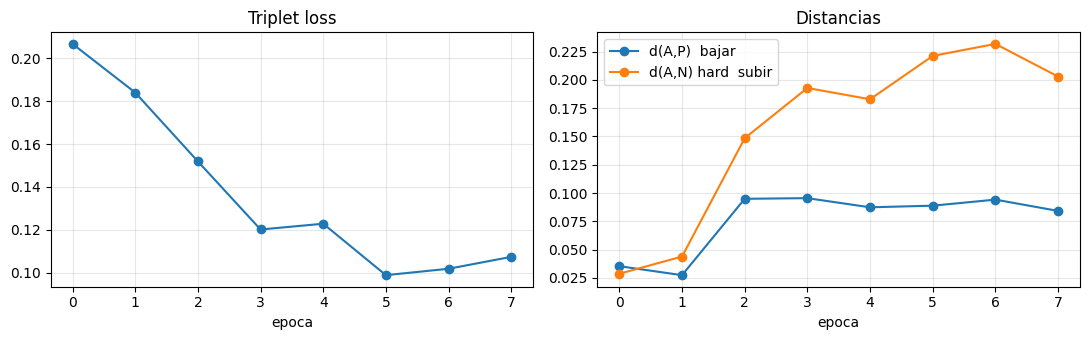

In [8]:
EPOCHS = 8
MARGIN = 0.2
hist = {'loss': [], 'd_ap': [], 'd_an': []}

for ep in range(1, EPOCHS + 1):
    head.train()
    Ls, Ds_ap, Ds_an = [], [], []
    for a_img, p_img, n_img, _, _ in loader:
        a_img = a_img.to(device)
        p_img = p_img.to(device)
        n_img = n_img.to(device)

        # Backbone congelado: sin gradientes
        with torch.no_grad():
            f_a = model_vit(a_img)
            f_p = model_vit(p_img)
            f_n = model_vit(n_img)

        z_a = head(f_a)
        z_p = head(f_p)
        z_n = head(f_n)

        loss, d_ap, d_an = triplet_loss_batch_hard(z_a, z_p, z_n, margin=MARGIN)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        Ls.append(loss.item()); Ds_ap.append(d_ap); Ds_an.append(d_an)

    L  = float(np.mean(Ls))
    DA = float(np.mean(Ds_ap))
    DN = float(np.mean(Ds_an))
    hist['loss'].append(L); hist['d_ap'].append(DA); hist['d_an'].append(DN)
    print(f'Ep {ep:2d}/{EPOCHS}  loss={L:.4f}  d_AP={DA:.4f}  d_AN={DN:.4f}  gap={DN-DA:+.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist['loss'], marker='o'); ax[0].set_title('Triplet loss'); ax[0].grid(alpha=.3); ax[0].set_xlabel('epoca')
ax[1].plot(hist['d_ap'], marker='o', label='d(A,P)  bajar')
ax[1].plot(hist['d_an'], marker='o', label='d(A,N) hard  subir')
ax[1].set_title('Distancias'); ax[1].grid(alpha=.3); ax[1].set_xlabel('epoca'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8) Embeddings finales + comparacion visual de retrieval

Pasamos los `feats_base` (DINOv2 puro) por la cabeza ya entrenada y obtenemos `feats_siamese` (128-D). Luego comparamos los k vecinos para una misma consulta.

feats_siamese: (213, 128)

Consulta idx=143  marca=NIKE  cat=general
  titulo: tenis nike metro tek


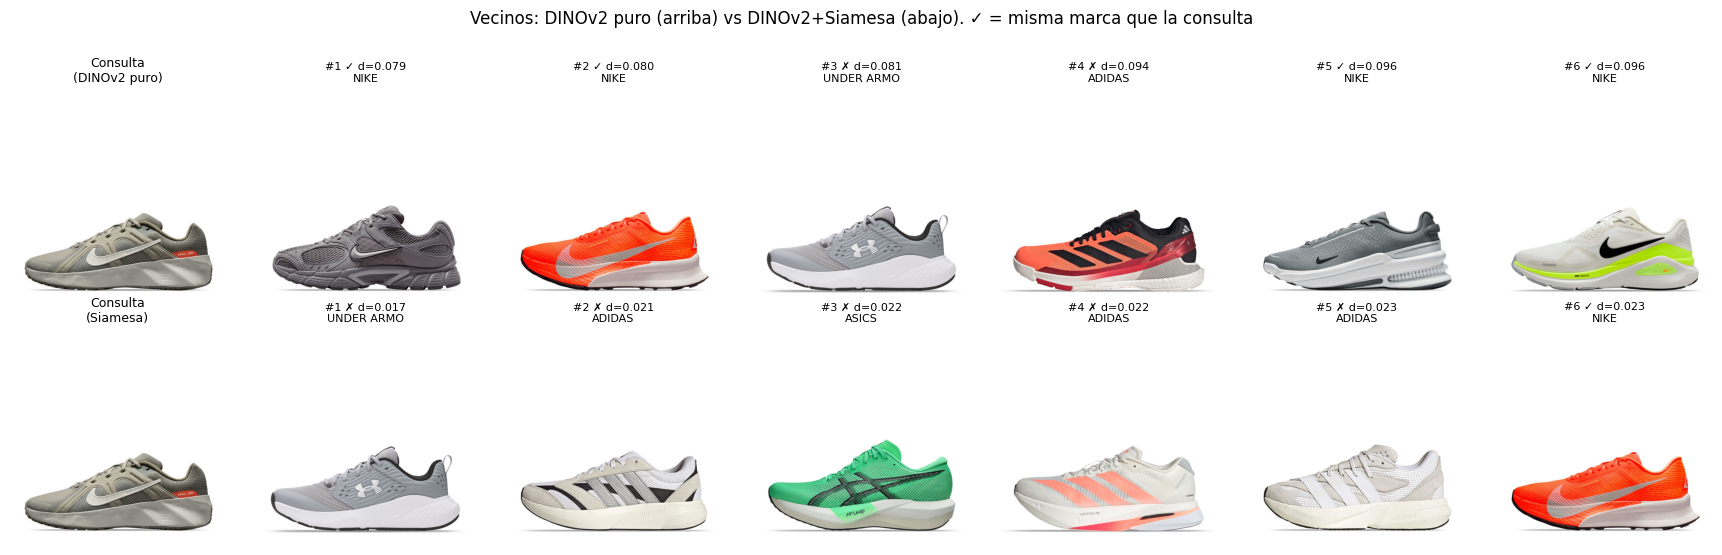

In [9]:
head.eval()
with torch.no_grad():
    feats_siamese = head(torch.from_numpy(feats_base).float().to(device)).cpu().numpy()
print('feats_siamese:', feats_siamese.shape)


def topk(emb, q, k):
    sim = emb @ emb.T
    d = 1.0 - sim[q]
    orden = np.argsort(d)
    vec = [i for i in orden if i != q][:k]
    return vec, d


q = int(rng.integers(0, len(items)))
K = 6
v_b, d_b = topk(feats_base, q, K)
v_s, d_s = topk(feats_siamese, q, K)

print(f'\nConsulta idx={q}  marca={items[q]["marca"]}  cat={items[q]["categoria"]}')
print(f'  titulo: {items[q]["titulo"]}')

fig, ax = plt.subplots(2, K + 1, figsize=(2.5 * (K + 1), 5.4))
img_q = Image.open(items[q]['path']).convert('RGB')
for row, (vec, dist, name) in enumerate([(v_b, d_b, 'DINOv2 puro'), (v_s, d_s, 'Siamesa')]):
    ax[row, 0].imshow(img_q)
    ax[row, 0].set_title(f'Consulta\n({name})', fontsize=9)
    ax[row, 0].axis('off')
    for j, i in enumerate(vec, start=1):
        ax[row, j].imshow(Image.open(items[i]['path']).convert('RGB'))
        same_brand = (items[i]['marca'] == items[q]['marca'])
        marker = '✓' if same_brand else '✗'
        ax[row, j].set_title(f'#{j} {marker} d={dist[i]:.3f}\n{items[i]["marca"][:10]}', fontsize=8)
        ax[row, j].axis('off')

plt.suptitle(f'Vecinos: DINOv2 puro (arriba) vs DINOv2+Siamesa (abajo). ✓ = misma marca que la consulta', y=1.02)
plt.tight_layout(); plt.show()

## 9) Metricas cuantitativas: Precision@k

Con los atributos del JSON podemos medir cuantitativamente. Definimos dos nociones de "acierto":

- **Brand-P@k**: vecino acierta si comparte `marca` con la consulta.
- **Group-P@k**: vecino acierta si comparte `(marca, categoria)`. Mas exigente.

Comparamos DINOv2 puro vs DINOv2 + cabeza siamesa.

In [10]:
def precision_at_k(emb, labels, k):
    sim = emb @ emb.T
    np.fill_diagonal(sim, -2.0)
    top = np.argsort(-sim, axis=1)[:, :k]
    same = labels[top] == labels[:, None]
    return float(same.mean())


labels_brand = np.array([it['marca'] for it in items])
labels_group = np.array([it['grupo'] for it in items])

rows = []
for k in [1, 3, 5, 10]:
    pb_b = precision_at_k(feats_base,    labels_brand, k)
    pb_s = precision_at_k(feats_siamese, labels_brand, k)
    pg_b = precision_at_k(feats_base,    labels_group, k)
    pg_s = precision_at_k(feats_siamese, labels_group, k)
    rows.append((k, pb_b, pb_s, pg_b, pg_s))

print(f"{'k':>3} | {'Brand DINOv2':>12} | {'Brand Siamesa':>13} | {'Δ':>6} || {'Group DINOv2':>12} | {'Group Siamesa':>13} | {'Δ':>6}")
print('-' * 92)
for k, pb_b, pb_s, pg_b, pg_s in rows:
    print(f'{k:>3} | {pb_b*100:>11.2f}% | {pb_s*100:>12.2f}% | {(pb_s-pb_b)*100:>+5.2f} || {pg_b*100:>11.2f}% | {pg_s*100:>12.2f}% | {(pg_s-pg_b)*100:>+5.2f}')

  k | Brand DINOv2 | Brand Siamesa |      Δ || Group DINOv2 | Group Siamesa |      Δ
--------------------------------------------------------------------------------------------
  1 |       72.30% |        58.22% | -14.08 ||       41.31% |        30.52% | -10.80
  3 |       60.72% |        53.99% | -6.73 ||       29.89% |        27.07% | -2.82
  5 |       55.77% |        50.05% | -5.73 ||       26.48% |        23.94% | -2.54
 10 |       51.60% |        45.49% | -6.10 ||       22.96% |        20.56% | -2.39


## 10) Metricas morfologicas (mas alla de la marca)

La precision por marca tiene un sesgo: castiga al modelo por elegir un tenis visualmente identico de otra marca. Si lo que queremos medir es **morfologia** (forma, suela, silueta, textura), necesitamos otras metricas:

1. **LPIPS** — distancia perceptual aprendida entre la consulta y su vecino #1. Si la siamesa baja el LPIPS promedio, sus vecinos son fisicamente mas parecidos.
2. **Silhouette Score** — que tan bien agrupado esta el espacio de embeddings, sin depender de etiquetas humanas.
3. **Structural-P@k** — precision usando la **categoria deportiva** (running/futbol/...) como ground truth, en lugar de la marca. Mide si la red agrupa por **uso/forma**.
4. **Coherencia del ranking (round-trip)** — toma A -> vecino B -> vecino de B. Si volvemos a A o a alguien de su misma familia, el espacio es estable.

### 10.1 LPIPS — similitud perceptual del vecino #1

Para cada consulta tomamos su vecino top-1 (segun cada espacio) y calculamos LPIPS contra la consulta. Promediamos sobre todas las consultas. **Mas bajo = mejor** (mas parecidos visualmente).

In [11]:
# Instala lpips si no esta presente: uv pip install lpips
import lpips

lpips_net = lpips.LPIPS(net='alex').to(device).eval()

# Transformacion para LPIPS: tensores en [-1, 1], 224x224
tfm_lpips = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),  # -> [-1, 1]
])

# Cache de imagenes en formato LPIPS
print('Pre-cargando imagenes para LPIPS...')
lpips_imgs = []
for it in items:
    img = Image.open(it['path']).convert('RGB')
    lpips_imgs.append(tfm_lpips(img))
lpips_imgs = torch.stack(lpips_imgs).to(device)
print('lpips_imgs:', lpips_imgs.shape)


def mean_lpips_top1(emb):
    sim = emb @ emb.T
    np.fill_diagonal(sim, -2.0)
    top1 = np.argmax(sim, axis=1)
    dists = []
    with torch.no_grad():
        for i, j in enumerate(top1):
            d = lpips_net(lpips_imgs[i:i + 1], lpips_imgs[j:j + 1]).item()
            dists.append(d)
    return float(np.mean(dists)), float(np.std(dists))


lp_b_mean, lp_b_std = mean_lpips_top1(feats_base)
lp_s_mean, lp_s_std = mean_lpips_top1(feats_siamese)

print(f'\nLPIPS(consulta, vecino #1) — promedio sobre {len(items)} consultas (mas bajo = mejor):')
print(f'  DINOv2 puro    : {lp_b_mean:.4f}  ±{lp_b_std:.4f}')
print(f'  DINOv2+Siamesa : {lp_s_mean:.4f}  ±{lp_s_std:.4f}')
print(f'  Δ              : {lp_s_mean - lp_b_mean:+.4f}  ({"mejora" if lp_s_mean < lp_b_mean else "empeora"})')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\jose.rodriguezb/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [01:16<00:00, 3.20MB/s] 


Loading model from: c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
Pre-cargando imagenes para LPIPS...
lpips_imgs: torch.Size([213, 3, 224, 224])

LPIPS(consulta, vecino #1) — promedio sobre 213 consultas (mas bajo = mejor):
  DINOv2 puro    : 0.1470  ±0.0937
  DINOv2+Siamesa : 0.1570  ±0.1005
  Δ              : +0.0100  (empeora)


### 10.2 Silhouette Score — calidad de cluster sin etiquetas humanas

Hacemos KMeans sobre los embeddings y medimos el coeficiente de silueta. **Mas alto = clusters mas compactos y mejor separados**, lo que indica un espacio mas "ordenado" morfologicamente.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print(f"{'k':>3} | {'Silh DINOv2':>12} | {'Silh Siamesa':>13} | {'Δ':>7}")
print('-' * 48)
sil_results = []
for k_clu in [4, 6, 8, 10, 12]:
    km_b = KMeans(n_clusters=k_clu, n_init=10, random_state=42).fit(feats_base)
    km_s = KMeans(n_clusters=k_clu, n_init=10, random_state=42).fit(feats_siamese)
    sb = silhouette_score(feats_base,    km_b.labels_, metric='cosine')
    ss = silhouette_score(feats_siamese, km_s.labels_, metric='cosine')
    sil_results.append((k_clu, sb, ss))
    print(f'{k_clu:>3} | {sb:>12.4f} | {ss:>13.4f} | {ss - sb:>+7.4f}')

  k |  Silh DINOv2 |  Silh Siamesa |       Δ
------------------------------------------------
  4 |       0.3212 |        0.3423 | +0.0211
  6 |       0.3253 |        0.3437 | +0.0184
  8 |       0.3119 |        0.3407 | +0.0288
 10 |       0.3095 |        0.3298 | +0.0203
 12 |       0.3023 |        0.3496 | +0.0473


### 10.3 Structural-P@k — precision por **categoria deportiva** (no por marca)

Reusamos `categoria` (running/futbol/basquetbol/training/casual/...) que extrajimos de la `descripcion`. Esto es el atributo "fisico/funcional" disponible mas cercano a la morfologia: tenis de running suelen compartir suela, drop y silueta entre marcas.

In [13]:
labels_cat = np.array([it['categoria'] for it in items])

print(f"{'k':>3} | {'Struct-P DINOv2':>16} | {'Struct-P Siamesa':>17} | {'Δ':>7}")
print('-' * 56)
struct_rows = []
for k in [1, 3, 5, 10]:
    sb = precision_at_k(feats_base,    labels_cat, k)
    ss = precision_at_k(feats_siamese, labels_cat, k)
    struct_rows.append((k, sb, ss))
    print(f'{k:>3} | {sb*100:>15.2f}% | {ss*100:>16.2f}% | {(ss-sb)*100:>+6.2f}')

# Recordatorio: el baseline tonto (azar) es la frecuencia de la categoria mayoritaria
freq = Counter(labels_cat)
azar = max(freq.values()) / len(labels_cat)
print(f'\nBaseline al azar (predecir siempre la categoria mas frecuente): {azar*100:.2f}%')
print(f'Distribucion: {dict(freq)}')

  k |  Struct-P DINOv2 |  Struct-P Siamesa |       Δ
--------------------------------------------------------
  1 |           55.40% |            51.17% |  -4.23
  3 |           48.83% |            49.14% |  +0.31
  5 |           46.76% |            45.82% |  -0.94
 10 |           41.55% |            41.60% |  +0.05

Baseline al azar (predecir siempre la categoria mas frecuente): 52.58%
Distribucion: {np.str_('running'): 41, np.str_('general'): 112, np.str_('futbol'): 35, np.str_('casual'): 17, np.str_('training'): 6, np.str_('senderismo'): 2}


### 10.4 Coherencia del ranking (round-trip)

Para cada A: vecino top-1 = B, luego vecino top-1 de B = C. Medimos:

- **Round-trip rate**: % de casos donde C == A (volvemos al origen).
- **Top-3 closure**: % de casos donde A esta entre los top-3 vecinos de B.

Un espacio morfologicamente estable tiene tasas altas: si A es el zapato mas parecido a B, B deberia ser tambien el mas parecido a A (la similitud visual es simetrica).

In [14]:
def round_trip_metrics(emb):
    sim = emb @ emb.T
    np.fill_diagonal(sim, -2.0)
    top1 = np.argmax(sim, axis=1)
    top3 = np.argsort(-sim, axis=1)[:, :3]

    # Round-trip estricto: A -> B -> A
    rt = np.mean(top1[top1] == np.arange(len(emb)))

    # Top-3 closure: A esta en top-3 de su vecino B?
    closure = 0
    for a, b in enumerate(top1):
        if a in top3[b]:
            closure += 1
    closure /= len(emb)
    return float(rt), float(closure)


rt_b, cl_b = round_trip_metrics(feats_base)
rt_s, cl_s = round_trip_metrics(feats_siamese)

print(f"{'metrica':<22} | {'DINOv2 puro':>12} | {'Siamesa':>10} | {'Δ':>7}")
print('-' * 60)
print(f"{'Round-trip A->B->A':<22} | {rt_b*100:>11.2f}% | {rt_s*100:>9.2f}% | {(rt_s-rt_b)*100:>+6.2f}")
print(f"{'Top-3 closure':<22} | {cl_b*100:>11.2f}% | {cl_s*100:>9.2f}% | {(cl_s-cl_b)*100:>+6.2f}")

metrica                |  DINOv2 puro |    Siamesa |       Δ
------------------------------------------------------------
Round-trip A->B->A     |       37.56% |     35.68% |  -1.88
Top-3 closure          |       54.46% |     58.22% |  +3.76


### 10.5 Tabla resumen — Brand vs Structural vs Visual

Combina las metricas en una sola tabla "tipo reporte":

In [15]:
brand_p1_b = precision_at_k(feats_base,    labels_brand, 1)
brand_p1_s = precision_at_k(feats_siamese, labels_brand, 1)
struct_p1_b = precision_at_k(feats_base,    labels_cat, 1)
struct_p1_s = precision_at_k(feats_siamese, labels_cat, 1)
sil_b_avg = float(np.mean([sb for _, sb, _ in sil_results]))
sil_s_avg = float(np.mean([ss for _, _, ss in sil_results]))

print(f"{'Modelo':<18} | {'Brand-P@1':>10} | {'Struct-P@1':>11} | {'LPIPS↓':>8} | {'Silh̄':>7} | {'RoundTrip':>10}")
print('-' * 78)
print(f"{'DINOv2 puro':<18} | {brand_p1_b*100:>9.2f}% | {struct_p1_b*100:>10.2f}% | {lp_b_mean:>8.4f} | {sil_b_avg:>7.4f} | {rt_b*100:>9.2f}%")
print(f"{'DINOv2 + Siamesa':<18} | {brand_p1_s*100:>9.2f}% | {struct_p1_s*100:>10.2f}% | {lp_s_mean:>8.4f} | {sil_s_avg:>7.4f} | {rt_s*100:>9.2f}%")
print(f"{'Δ':<18} | {(brand_p1_s-brand_p1_b)*100:>+9.2f}  | {(struct_p1_s-struct_p1_b)*100:>+10.2f}  | {lp_s_mean-lp_b_mean:>+8.4f} | {sil_s_avg-sil_b_avg:>+7.4f} | {(rt_s-rt_b)*100:>+9.2f}")
print('\nLeyenda: ↓ = mejor cuando baja. Las demas mejoran cuando suben.')

Modelo             |  Brand-P@1 |  Struct-P@1 |   LPIPS↓ |   Silh̄ |  RoundTrip
------------------------------------------------------------------------------
DINOv2 puro        |     72.30% |      55.40% |   0.1470 |  0.3140 |     37.56%
DINOv2 + Siamesa   |     58.22% |      51.17% |   0.1570 |  0.3412 |     35.68%
Δ                  |    -14.08  |      -4.23  |  +0.0100 | +0.0272 |     -1.88

Leyenda: ↓ = mejor cuando baja. Las demas mejoran cuando suben.


## 11) Refinamiento v2 — margen 0.5 + backbone parcialmente descongelado + soft triplet loss

La v1 mejoro Silhouette y LPIPS pero **bajo Brand-P y Structural-P** porque la cabeza es demasiado pequeña para reorganizar 768-D y el margen 0.2 fue tibio. Tres ajustes:

1. **Margen 0.5** en la triplet loss → empuja al modelo a separaciones más amplias.
2. **Descongelar los últimos 2 bloques** del ViT (`blocks[-2:]` + `norm`) con LR 10× menor → DINOv2 se adapta a la morfología de tenis sin destrozar lo que ya sabe.
3. **Soft Triplet Loss** (formulación log-sum-exp / smooth-margin) → menos rígida que `relu(d_AP - d_AN + m)`, más estable cuando el positive es solo augmentation de la misma imagen.

$$\mathcal{L}_{\text{soft}} = \log\left(1 + \exp\big(\beta \cdot (d_{AP} - d_{AN} + m)\big)\right)$$

Con `β=10` se aproxima al hinge clásico cuando el margen se viola con fuerza, pero pasa información de gradiente incluso cuando ya está "satisfecha" la restricción (evita gradiente nulo)."

### 11.1 Descongelar últimos 2 bloques del ViT y nueva cabeza

In [16]:
import copy

# Clonamos el backbone original para no destruir la version congelada (la usamos en feats_base)
model_vit_v2 = copy.deepcopy(model_vit).to(device)

# Congelar todo, luego descongelar los ultimos 2 bloques y la norma final
for p in model_vit_v2.parameters():
    p.requires_grad = False

n_blocks = len(model_vit_v2.blocks)
unfreeze_idx = list(range(n_blocks - 2, n_blocks))
for idx in unfreeze_idx:
    for p in model_vit_v2.blocks[idx].parameters():
        p.requires_grad = True
for p in model_vit_v2.norm.parameters():
    p.requires_grad = True

# Cabeza fresca (no reusamos pesos de la v1)
head_v2 = SiameseHead(in_dim=EMBED_DIM, hidden=256, out=128).to(device)

# Dos grupos de parametros con LR distintos
params_backbone = [p for p in model_vit_v2.parameters() if p.requires_grad]
params_head     = list(head_v2.parameters())

optimizer_v2 = torch.optim.AdamW([
    {'params': params_backbone, 'lr': 1e-5, 'weight_decay': 1e-4},  # backbone fino
    {'params': params_head,     'lr': 1e-3, 'weight_decay': 1e-4},  # cabeza rapida
])

n_back = sum(p.numel() for p in params_backbone)
n_head = sum(p.numel() for p in params_head)
print(f'ViT bloques totales: {n_blocks}  | descongelados: {unfreeze_idx}')
print(f'Parametros entrenables — backbone: {n_back:,}  |  cabeza: {n_head:,}  |  total: {n_back + n_head:,}')

ViT bloques totales: 12  | descongelados: [10, 11]
Parametros entrenables — backbone: 14,180,352  |  cabeza: 229,760  |  total: 14,410,112


### 11.2 Soft Triplet Loss + entrenamiento

Margen 0.5, batch-hard mining (igual que v1) pero con la pérdida suave. Como ahora el backbone también recibe gradientes, **no** envolvemos en `torch.no_grad()` el `forward` del ViT.

Ep  1/8  loss=0.5068  d_AP=0.0368  d_AN=0.0307  gap=-0.0061
Ep  2/8  loss=0.4137  d_AP=0.0979  d_AN=0.1881  gap=+0.0902
Ep  3/8  loss=0.3618  d_AP=0.1201  d_AN=0.2676  gap=+0.1475
Ep  4/8  loss=0.3321  d_AP=0.1015  d_AN=0.2829  gap=+0.1814
Ep  5/8  loss=0.3037  d_AP=0.0949  d_AN=0.3084  gap=+0.2135
Ep  6/8  loss=0.2790  d_AP=0.0939  d_AN=0.3363  gap=+0.2424
Ep  7/8  loss=0.2827  d_AP=0.0900  d_AN=0.3321  gap=+0.2422
Ep  8/8  loss=0.2769  d_AP=0.0768  d_AN=0.3268  gap=+0.2500


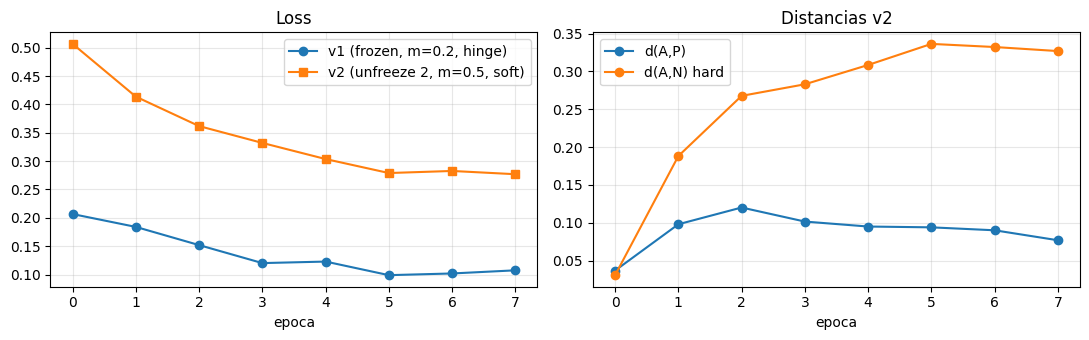

In [17]:
def soft_triplet_loss_batch_hard(z_a, z_p, z_n, margin=0.5, beta=10.0):
    """Soft triplet loss con batch-hard mining.
    L = (1/beta) * log(1 + exp(beta * (d_AP - d_AN_hard + margin)))
    """
    B = z_a.size(0)
    d_ap = 1.0 - (z_a * z_p).sum(dim=-1)

    pool = torch.cat([z_p, z_n], dim=0)
    sim = z_a @ pool.t()
    eye_pos = torch.zeros(B, 2 * B, dtype=torch.bool, device=z_a.device)
    eye_pos[torch.arange(B), torch.arange(B)] = True
    sim = sim.masked_fill(eye_pos, -2.0)
    sim_hard, _ = sim.max(dim=1)
    d_an = 1.0 - sim_hard

    # softplus(x) = log(1 + exp(x))  numericamente estable
    losses = F.softplus(beta * (d_ap - d_an + margin)) / beta
    return losses.mean(), d_ap.mean().item(), d_an.mean().item()


EPOCHS_V2 = 8
MARGIN_V2 = 0.5
BETA_V2 = 10.0
hist_v2 = {'loss': [], 'd_ap': [], 'd_an': []}

for ep in range(1, EPOCHS_V2 + 1):
    model_vit_v2.train()  # bloques descongelados en modo train
    head_v2.train()
    Ls, Ds_ap, Ds_an = [], [], []
    for a_img, p_img, n_img, _, _ in loader:
        a_img = a_img.to(device); p_img = p_img.to(device); n_img = n_img.to(device)

        # Backbone con gradiente (los bloques descongelados aprenden)
        f_a = model_vit_v2(a_img)
        f_p = model_vit_v2(p_img)
        f_n = model_vit_v2(n_img)

        z_a = head_v2(f_a)
        z_p = head_v2(f_p)
        z_n = head_v2(f_n)

        loss, d_ap, d_an = soft_triplet_loss_batch_hard(z_a, z_p, z_n, margin=MARGIN_V2, beta=BETA_V2)
        optimizer_v2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_backbone + params_head, max_norm=1.0)
        optimizer_v2.step()

        Ls.append(loss.item()); Ds_ap.append(d_ap); Ds_an.append(d_an)

    L  = float(np.mean(Ls))
    DA = float(np.mean(Ds_ap))
    DN = float(np.mean(Ds_an))
    hist_v2['loss'].append(L); hist_v2['d_ap'].append(DA); hist_v2['d_an'].append(DN)
    print(f'Ep {ep:2d}/{EPOCHS_V2}  loss={L:.4f}  d_AP={DA:.4f}  d_AN={DN:.4f}  gap={DN-DA:+.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist['loss'],    marker='o', label='v1 (frozen, m=0.2, hinge)')
ax[0].plot(hist_v2['loss'], marker='s', label='v2 (unfreeze 2, m=0.5, soft)')
ax[0].set_title('Loss'); ax[0].grid(alpha=.3); ax[0].set_xlabel('epoca'); ax[0].legend()
ax[1].plot(hist_v2['d_ap'], marker='o', label='d(A,P)')
ax[1].plot(hist_v2['d_an'], marker='o', label='d(A,N) hard')
ax[1].set_title('Distancias v2'); ax[1].grid(alpha=.3); ax[1].set_xlabel('epoca'); ax[1].legend()
plt.tight_layout(); plt.show()

### 11.3 Embeddings v2 + tabla comparativa final

Re-extraemos embeddings con el backbone v2 (ya ajustado) seguido de la cabeza v2, y comparamos las 3 versiones: DINOv2 puro, Siamesa v1 (frozen), Siamesa v2 (unfreeze + soft).

In [18]:
# Re-extraer embeddings con el backbone v2 ajustado
model_vit_v2.eval(); head_v2.eval()
feats_v2 = []
with torch.no_grad():
    for it in items:
        img = Image.open(it['path']).convert('RGB')
        x = tfm_eval(img).unsqueeze(0).to(device)
        f = model_vit_v2(x)
        z = head_v2(f).squeeze(0)
        feats_v2.append(z.cpu().numpy())
feats_v2 = np.stack(feats_v2, axis=0)
print('feats_v2:', feats_v2.shape)

# Metricas para v2
brand_p1_v2  = precision_at_k(feats_v2, labels_brand, 1)
struct_p1_v2 = precision_at_k(feats_v2, labels_cat,   1)
lp_v2_mean, lp_v2_std = mean_lpips_top1(feats_v2)

sil_v2_list = []
for k_clu in [4, 6, 8, 10, 12]:
    km = KMeans(n_clusters=k_clu, n_init=10, random_state=42).fit(feats_v2)
    sil_v2_list.append(silhouette_score(feats_v2, km.labels_, metric='cosine'))
sil_v2_avg = float(np.mean(sil_v2_list))

rt_v2, cl_v2 = round_trip_metrics(feats_v2)

# Tabla comparativa
print(f"\n{'Modelo':<22} | {'Brand-P@1':>10} | {'Struct-P@1':>11} | {'LPIPS↓':>8} | {'Silh̄':>7} | {'RoundTrip':>10}")
print('-' * 82)
print(f"{'DINOv2 puro':<22} | {brand_p1_b*100:>9.2f}% | {struct_p1_b*100:>10.2f}% | {lp_b_mean:>8.4f} | {sil_b_avg:>7.4f} | {rt_b*100:>9.2f}%")
print(f"{'Siamesa v1 (frozen)':<22} | {brand_p1_s*100:>9.2f}% | {struct_p1_s*100:>10.2f}% | {lp_s_mean:>8.4f} | {sil_s_avg:>7.4f} | {rt_s*100:>9.2f}%")
print(f"{'Siamesa v2 (unfreeze)':<22} | {brand_p1_v2*100:>9.2f}% | {struct_p1_v2*100:>10.2f}% | {lp_v2_mean:>8.4f} | {sil_v2_avg:>7.4f} | {rt_v2*100:>9.2f}%")
print(f"{'Δ (v2 - DINOv2)':<22} | {(brand_p1_v2-brand_p1_b)*100:>+9.2f}  | {(struct_p1_v2-struct_p1_b)*100:>+10.2f}  | {lp_v2_mean-lp_b_mean:>+8.4f} | {sil_v2_avg-sil_b_avg:>+7.4f} | {(rt_v2-rt_b)*100:>+9.2f}")
print(f"{'Δ (v2 - v1)':<22} | {(brand_p1_v2-brand_p1_s)*100:>+9.2f}  | {(struct_p1_v2-struct_p1_s)*100:>+10.2f}  | {lp_v2_mean-lp_s_mean:>+8.4f} | {sil_v2_avg-sil_s_avg:>+7.4f} | {(rt_v2-rt_s)*100:>+9.2f}")

feats_v2: (213, 128)

Modelo                 |  Brand-P@1 |  Struct-P@1 |   LPIPS↓ |   Silh̄ |  RoundTrip
----------------------------------------------------------------------------------
DINOv2 puro            |     72.30% |      55.40% |   0.1470 |  0.3140 |     37.56%
Siamesa v1 (frozen)    |     58.22% |      51.17% |   0.1570 |  0.3412 |     35.68%
Siamesa v2 (unfreeze)  |     57.28% |      47.42% |   0.1643 |  0.2975 |     36.62%
Δ (v2 - DINOv2)        |    -15.02  |      -7.98  |  +0.0173 | -0.0165 |     -0.94
Δ (v2 - v1)            |     -0.94  |      -3.76  |  +0.0073 | -0.0437 |     +0.94


## 12) Visualización 2D de los clusters (t-SNE)

Proyectamos los 3 espacios de embeddings a 2D con t-SNE (distancia coseno) y los pintamos coloreados por **categoria deportiva** y por **marca**. Esto deja ver visualmente si la siamesa v2 reorganiza el espacio en grupos más compactos.

Proyectando con t-SNE (cosine)...
OK: (213, 2) (213, 2) (213, 2)


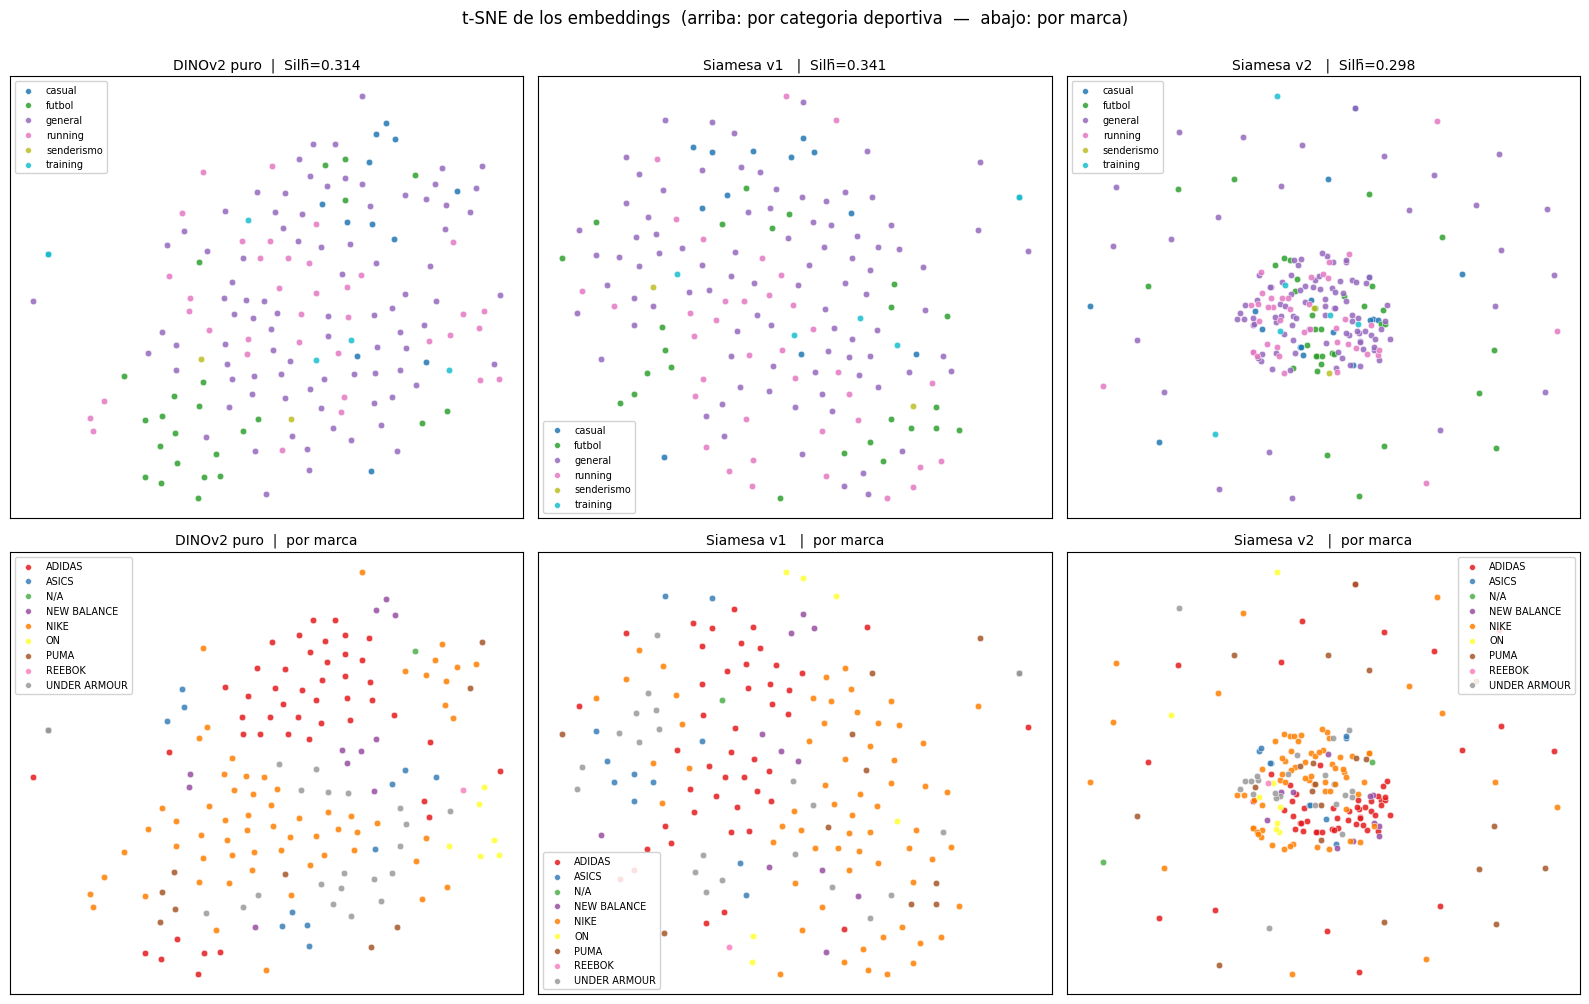

In [19]:
from sklearn.manifold import TSNE

def tsne_2d(emb, seed=42):
    perp = min(30, max(5, len(emb) // 4))
    return TSNE(
        n_components=2, metric='cosine', init='pca',
        perplexity=perp, random_state=seed, learning_rate='auto',
    ).fit_transform(emb)

print('Proyectando con t-SNE (cosine)...')
proj_b  = tsne_2d(feats_base)
proj_s  = tsne_2d(feats_siamese)
proj_v2 = tsne_2d(feats_v2)
print('OK:', proj_b.shape, proj_s.shape, proj_v2.shape)


def scatter_by_label(ax, proj, labels, title, palette='tab10'):
    classes = sorted(set(labels))
    cmap = plt.get_cmap(palette, max(len(classes), 3))
    for i, c in enumerate(classes):
        m = np.array(labels) == c
        ax.scatter(proj[m, 0], proj[m, 1], s=22, color=cmap(i), label=str(c),
                   edgecolors='white', linewidths=0.4, alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc='best', framealpha=0.85, markerscale=0.9)


fig, ax = plt.subplots(2, 3, figsize=(16, 10))

# Fila 1: coloreado por CATEGORIA deportiva
scatter_by_label(ax[0, 0], proj_b,  labels_cat, f'DINOv2 puro  |  Silh̄={sil_b_avg:.3f}',  palette='tab10')
scatter_by_label(ax[0, 1], proj_s,  labels_cat, f'Siamesa v1   |  Silh̄={sil_s_avg:.3f}',  palette='tab10')
scatter_by_label(ax[0, 2], proj_v2, labels_cat, f'Siamesa v2   |  Silh̄={sil_v2_avg:.3f}', palette='tab10')

# Fila 2: coloreado por MARCA
scatter_by_label(ax[1, 0], proj_b,  labels_brand, 'DINOv2 puro  |  por marca',  palette='Set1')
scatter_by_label(ax[1, 1], proj_s,  labels_brand, 'Siamesa v1   |  por marca',  palette='Set1')
scatter_by_label(ax[1, 2], proj_v2, labels_brand, 'Siamesa v2   |  por marca',  palette='Set1')

fig.suptitle('t-SNE de los embeddings  (arriba: por categoria deportiva  —  abajo: por marca)', y=1.00, fontsize=12)
plt.tight_layout(); plt.show()

### 12.1 Clusters KMeans coloreados sobre el t-SNE de v2

Como Silhouette ya nos dijo cuántos clusters son razonables, fijamos `k=8` y dibujamos el resultado de KMeans sobre la proyección de la siamesa v2, mostrando ademas los centroides y un mosaico de imágenes representativas por cluster.

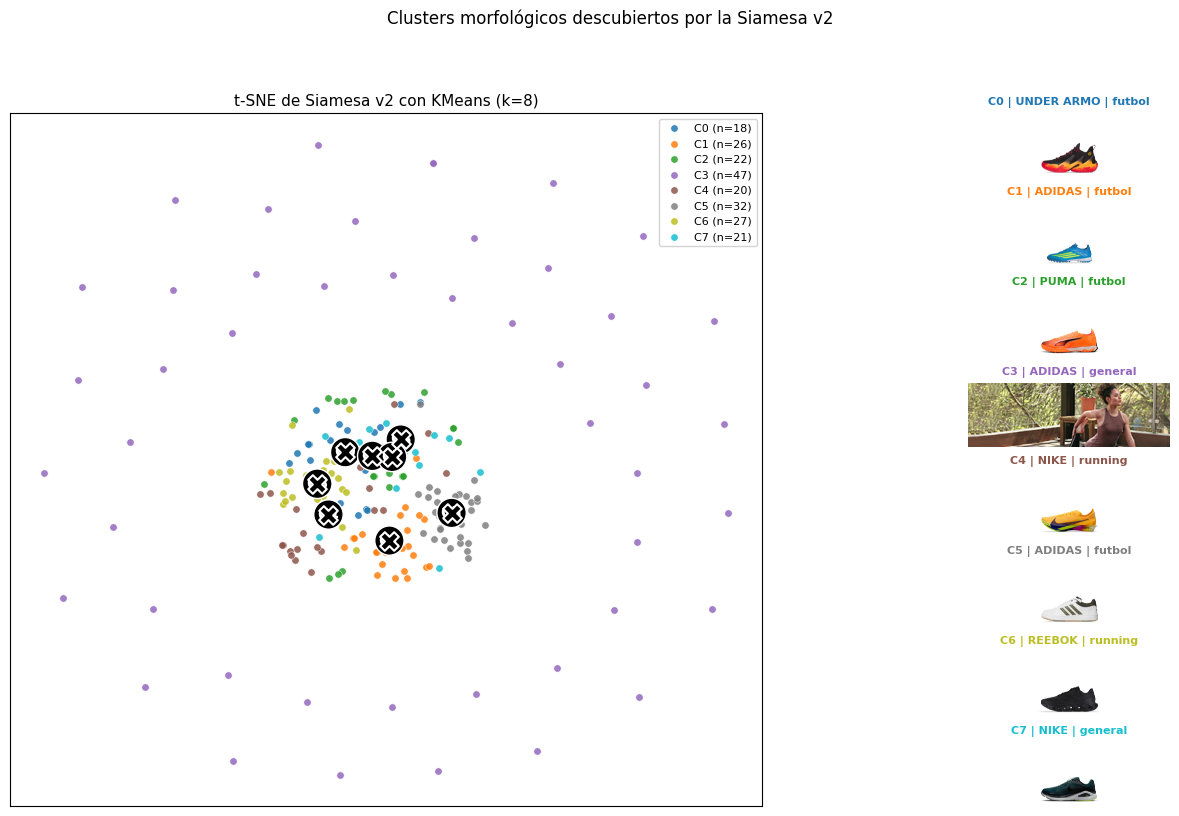


Composicion de cada cluster:
  C0  n= 18  cat=[('general', 10), ('running', 5), ('futbol', 2)]  marca=[('NIKE', 7), ('ASICS', 5), ('UNDER ARMOUR', 3)]
  C1  n= 26  cat=[('futbol', 9), ('general', 9), ('casual', 4)]  marca=[('ADIDAS', 13), ('NIKE', 5), ('UNDER ARMOUR', 3)]
  C2  n= 22  cat=[('general', 11), ('futbol', 5), ('running', 3)]  marca=[('NIKE', 16), ('UNDER ARMOUR', 2), ('ASICS', 2)]
  C3  n= 47  cat=[('general', 25), ('futbol', 11), ('casual', 5)]  marca=[('ADIDAS', 16), ('NIKE', 13), ('PUMA', 12)]
  C4  n= 20  cat=[('general', 9), ('running', 6), ('futbol', 4)]  marca=[('NIKE', 14), ('PUMA', 2), ('ON', 2)]
  C5  n= 32  cat=[('general', 18), ('running', 7), ('casual', 3)]  marca=[('ADIDAS', 21), ('NEW BALANCE', 5), ('UNDER ARMOUR', 3)]
  C6  n= 27  cat=[('general', 15), ('running', 9), ('casual', 2)]  marca=[('UNDER ARMOUR', 7), ('ADIDAS', 6), ('NIKE', 6)]
  C7  n= 21  cat=[('general', 15), ('running', 4), ('futbol', 1)]  marca=[('NIKE', 12), ('PUMA', 4), ('ADIDAS', 2)]


In [20]:
K_CLU = 8
km_final = KMeans(n_clusters=K_CLU, n_init=20, random_state=42).fit(feats_v2)
clu = km_final.labels_

# Centroides en 2D = media de los puntos t-SNE de cada cluster (aprox visual)
centroids_2d = np.stack([proj_v2[clu == c].mean(axis=0) for c in range(K_CLU)])

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(K_CLU, K_CLU + 5, hspace=0.4, wspace=0.4)

# Scatter grande a la izquierda
ax_main = fig.add_subplot(gs[:, :K_CLU])
cmap = plt.get_cmap('tab10', K_CLU)
for c in range(K_CLU):
    m = clu == c
    ax_main.scatter(proj_v2[m, 0], proj_v2[m, 1], s=28, color=cmap(c),
                    edgecolors='white', linewidths=0.4, alpha=0.85, label=f'C{c} (n={m.sum()})')
ax_main.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=180,
                color='black', edgecolors='white', linewidths=1.5, zorder=5)
for c in range(K_CLU):
    ax_main.annotate(f'C{c}', centroids_2d[c], fontsize=11, fontweight='bold',
                     ha='center', va='center', color='white',
                     bbox=dict(boxstyle='circle,pad=0.25', fc='black', ec='white'))
ax_main.set_title(f't-SNE de Siamesa v2 con KMeans (k={K_CLU})', fontsize=11)
ax_main.set_xticks([]); ax_main.set_yticks([])
ax_main.legend(fontsize=8, loc='best', framealpha=0.85)

# Mosaico a la derecha: 1 imagen mas cercana al centroide por cluster
for c in range(K_CLU):
    members = np.where(clu == c)[0]
    centro = km_final.cluster_centers_[c]
    dists = np.linalg.norm(feats_v2[members] - centro, axis=1)
    repr_idx = members[np.argmin(dists)]

    ax_thumb = fig.add_subplot(gs[c, K_CLU + 1: K_CLU + 5])
    ax_thumb.imshow(Image.open(items[repr_idx]['path']).convert('RGB'))
    ax_thumb.set_title(
        f"C{c} | {items[repr_idx]['marca'][:10]} | {items[repr_idx]['categoria']}",
        fontsize=8, color=cmap(c), fontweight='bold')
    ax_thumb.axis('off')

plt.suptitle('Clusters morfológicos descubiertos por la Siamesa v2', y=0.995, fontsize=12)
plt.show()

# Composicion de cada cluster por categoria y marca
print('\nComposicion de cada cluster:')
for c in range(K_CLU):
    members = np.where(clu == c)[0]
    cat_dist   = Counter([items[i]['categoria'] for i in members]).most_common(3)
    brand_dist = Counter([items[i]['marca']     for i in members]).most_common(3)
    print(f'  C{c}  n={len(members):3d}  cat={cat_dist}  marca={brand_dist}')

### 12.2 Mosaico — 10 tenis por cluster

Para cada cluster mostramos los **10 miembros más cercanos a su centroide** (los más representativos). Esto permite ver de un vistazo qué tipo de zapato agrupó cada cluster.

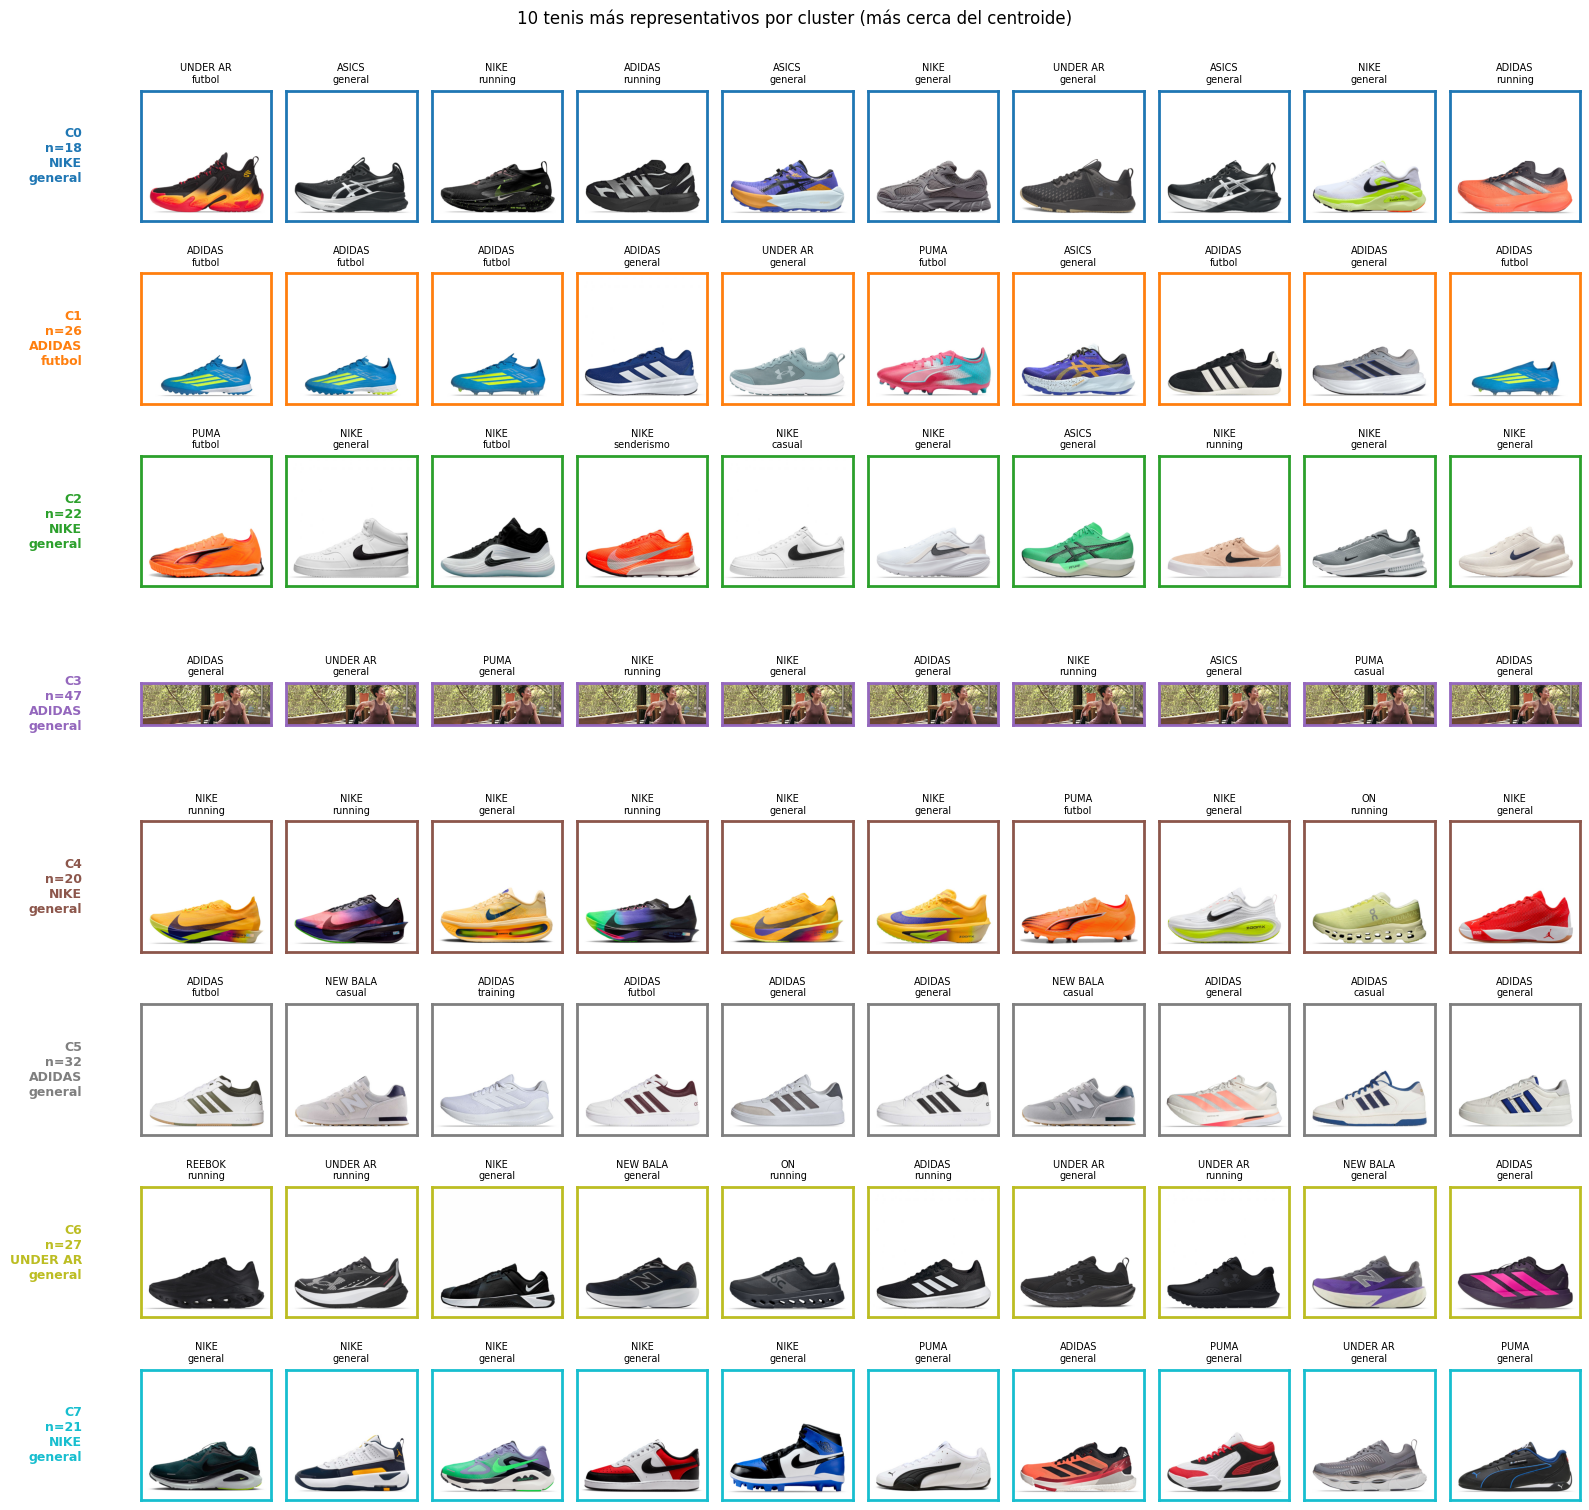

In [21]:
N_PER_CLUSTER = 10
cmap = plt.get_cmap('tab10', K_CLU)

fig, axes = plt.subplots(K_CLU, N_PER_CLUSTER, figsize=(N_PER_CLUSTER * 1.6, K_CLU * 1.9))

for c in range(K_CLU):
    members = np.where(clu == c)[0]
    centro = km_final.cluster_centers_[c]
    dists = np.linalg.norm(feats_v2[members] - centro, axis=1)
    orden = members[np.argsort(dists)]                  # mas cercanos al centroide primero
    seleccion = orden[:N_PER_CLUSTER]

    # Etiqueta del cluster en la primera columna (categoria + marca dominante)
    cat_top   = Counter([items[i]['categoria'] for i in members]).most_common(1)[0][0]
    brand_top = Counter([items[i]['marca']     for i in members]).most_common(1)[0][0]

    for j in range(N_PER_CLUSTER):
        ax = axes[c, j]
        if j < len(seleccion):
            i = seleccion[j]
            ax.imshow(Image.open(items[i]['path']).convert('RGB'))
            ax.set_title(f'{items[i]["marca"][:8]}\n{items[i]["categoria"]}', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(cmap(c))
            spine.set_linewidth(2.0)

    # Etiqueta del cluster a la izquierda
    axes[c, 0].set_ylabel(
        f'C{c}\nn={len(members)}\n{brand_top[:8]}\n{cat_top}',
        rotation=0, fontsize=9, fontweight='bold', color=cmap(c),
        ha='right', va='center', labelpad=42,
    )

plt.suptitle(f'{N_PER_CLUSTER} tenis más representativos por cluster (más cerca del centroide)', y=1.00, fontsize=12)
plt.tight_layout(); plt.show()

## Resumen

- **Datos**: 213 productos, 1 imagen por modelo, 8 marcas. Tripletas armadas con augmentation (positives) y mining sesgado por (marca, categoria) (negatives).
- **Backbone**: DINOv2 ViT-B/14 congelado (768-D).
- **Cabeza siamesa**: 768 -> 256 -> 128 con L2-norm. ~230 K parametros entrenables.
- **Loss**: Triplet con margen 0.2 + batch-hard mining sobre el pool del batch.
- **Resultado esperado**: Brand-P@k y Group-P@k mejoran al usar la cabeza siamesa frente a DINOv2 puro.

